In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving kaggle (2).json to kaggle (2).json


In [ ]:
!mv "kaggle (2).json" kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle --version

Kaggle CLI 2.0.2


In [ ]:
!kaggle datasets list -s mammography

ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/mias-mammography                                         MIAS Mammography                                      326653075  2017-11-01 10:50:49.467000          23924        260  0.75             
skooch/ddsm-mammography                                         DDSM Mammography                                     3093452937  2018-07-03 08:38:28.307000          11213        193  0.75             
ahmadihossein/csaw-cc-mammography                               CSAW-CC (mammography)                                   2171727  2024-11-25 06:55:19.553000            432         26  1            

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:35<00:00, 152MB/s]



In [ ]:
!ls

cbis-ddsm-breast-cancer-image-dataset.zip  kaggle.json	sample_data


In [ ]:
!find /content/ddsm | head -30

find: ‘/content/ddsm’: No such file or directory


In [ ]:
import os

for root, dirs, files in os.walk('/content/ddsm'):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

In [ ]:
!unzip -q cbis-ddsm-breast-cancer-image-dataset.zip -d /content/ddsm

In [ ]:
!ls /content

cbis-ddsm-breast-cancer-image-dataset.zip  ddsm  kaggle.json  sample_data


In [ ]:
!find /content/ddsm | head -50

/content/ddsm
/content/ddsm/jpeg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.185401704612037921031992536423384183051
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.185401704612037921031992536423384183051/1-251.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334/2-271.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334/1-293.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.201343023312572202611149257572758552350
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.201343023312572202611149257572758552350/1-271.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852/2-274.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852/1-273.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.15680520341292003724095

In [ ]:
import os

image_paths = []

for root, dirs, files in os.walk('/content/ddsm/jpeg'):
    for file in files:
        if file.endswith('.jpg'):
            image_paths.append(os.path.join(root, file))

print("Total mammograms:", len(image_paths))

Total mammograms: 10237


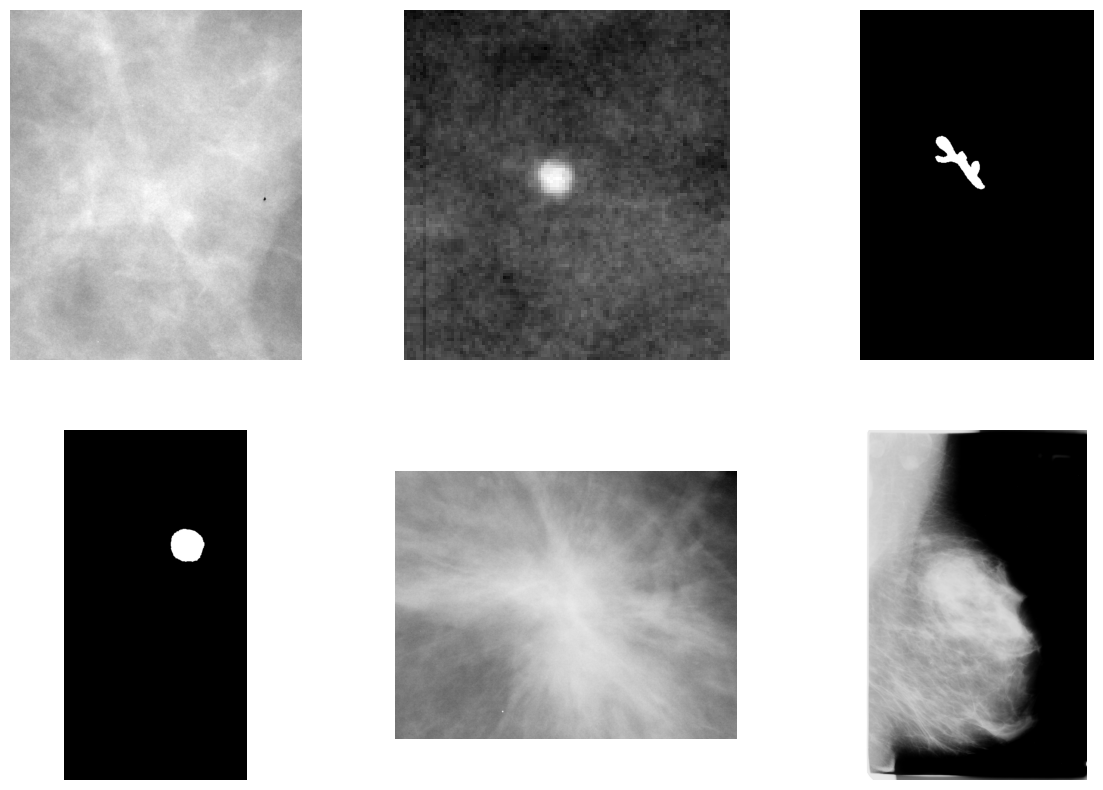

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample = random.sample(image_paths, 6)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

for a, path in zip(ax.ravel(), sample):
    img = Image.open(path)
    a.imshow(img, cmap='gray')
    a.axis('off')

plt.show()

In [ ]:
sizes = []

for path in image_paths:
    img = Image.open(path)
    sizes.append(img.size)

import pandas as pd

size_df = pd.DataFrame(
    sizes,
    columns=['Width', 'Height']
)

size_df.describe()

,Width,Height
count,10237.000000,10237.000000
mean,2179.893328,3549.778841
std,1374.221082,2363.196643
min,68.000000,73.000000
25%,453.000000,441.000000
50%,2728.000000,4624.000000
75%,3112.000000,5476.000000
max,5431.000000,7111.000000


In [ ]:
import glob

csv_files = glob.glob('/content/ddsm/**/*.csv', recursive=True)
print(csv_files)

['/content/ddsm/csv/mass_case_description_train_set.csv', '/content/ddsm/csv/dicom_info.csv', '/content/ddsm/csv/meta.csv', '/content/ddsm/csv/mass_case_description_test_set.csv', '/content/ddsm/csv/calc_case_description_test_set.csv', '/content/ddsm/csv/calc_case_description_train_set.csv']


In [ ]:
import pandas as pd

dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except:
        pass

data = pd.concat(dfs, ignore_index=True)
data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,...,StudyDate,StudyID,StudyInstanceUID,StudyTime,Collection,Visibility,ImageCount,breast density,calc type,calc distribution
0,P_00001,3.0,LEFT,CC,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1.0,mass,OVAL,CIRCUMSCRIBED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data['pathology'].value_counts()

,count
pathology,
MALIGNANT,1457
BENIGN,1429
BENIGN_WITHOUT_CALLBACK,682


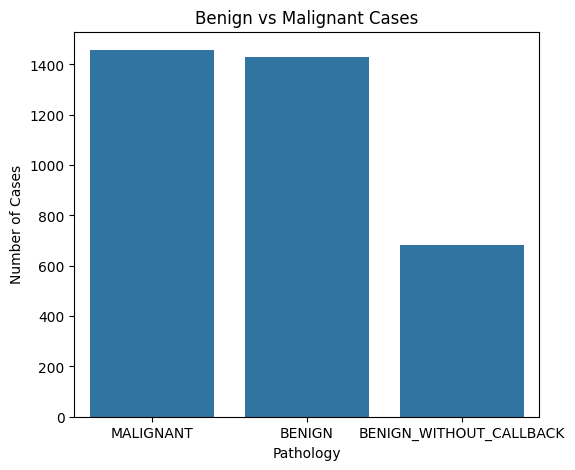

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='pathology', data=data)

plt.title('Benign vs Malignant Cases')
plt.xlabel('Pathology')
plt.ylabel('Number of Cases')
plt.show()

In [ ]:

data['image view'].value_counts()

,count
image view,
MLO,1896
CC,1672


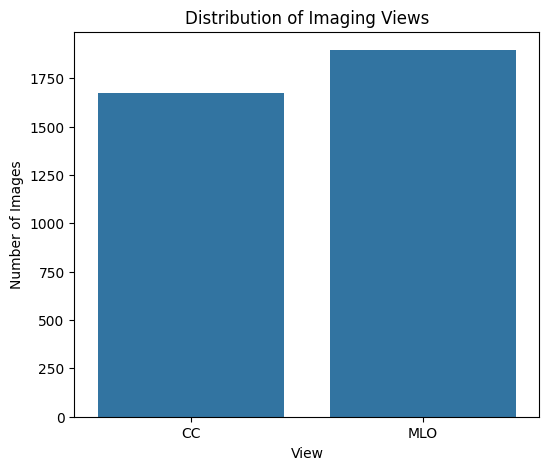

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='image view',
    data=data
)

plt.title('Distribution of Imaging Views')
plt.xlabel('View')
plt.ylabel('Number of Images')
plt.show()

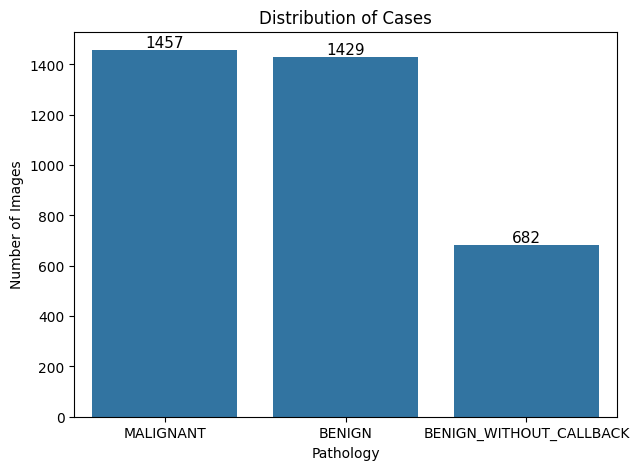

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
ax = sns.countplot(
    x='pathology',
    data=data,
    order=data['pathology'].value_counts().index
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Distribution of Cases')
plt.xlabel('Pathology')
plt.ylabel('Number of Images')
plt.show()

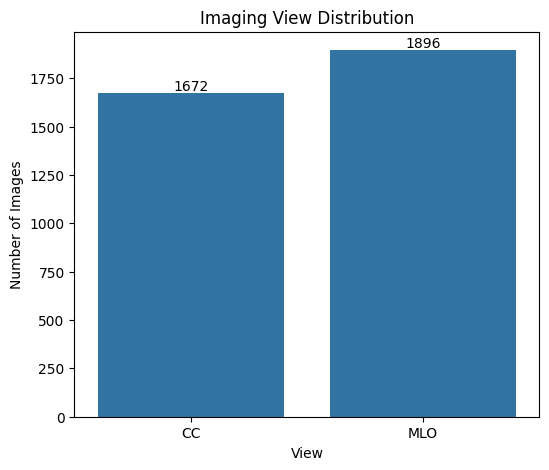

In [ ]:
plt.figure(figsize=(6,5))
ax = sns.countplot(
    x='image view',
    data=data
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Imaging View Distribution')
plt.xlabel('View')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
data['mass shape'].value_counts()

,count
mass shape,
IRREGULAR,464
OVAL,412
LOBULATED,384
ROUND,164
ARCHITECTURAL_DISTORTION,103
IRREGULAR-ARCHITECTURAL_DISTORTION,52
LYMPH_NODE,35
FOCAL_ASYMMETRIC_DENSITY,25
ASYMMETRIC_BREAST_TISSUE,25


In [ ]:
data['calc type'].value_counts()

,count
calc type,
PLEOMORPHIC,813
AMORPHOUS,181
PUNCTATE,132
LUCENT_CENTER,110
FINE_LINEAR_BRANCHING,102
VASCULAR,90
COARSE,39
PLEOMORPHIC-FINE_LINEAR_BRANCHING,31
ROUND_AND_REGULAR-LUCENT_CENTER,31


In [ ]:
mass_df = data[data['abnormality type'] == 'mass']
calc_df = data[data['abnormality type'] == 'calcification']

lesion_counts = {
    'Mass': len(mass_df),
    'Calcification': len(calc_df)
}

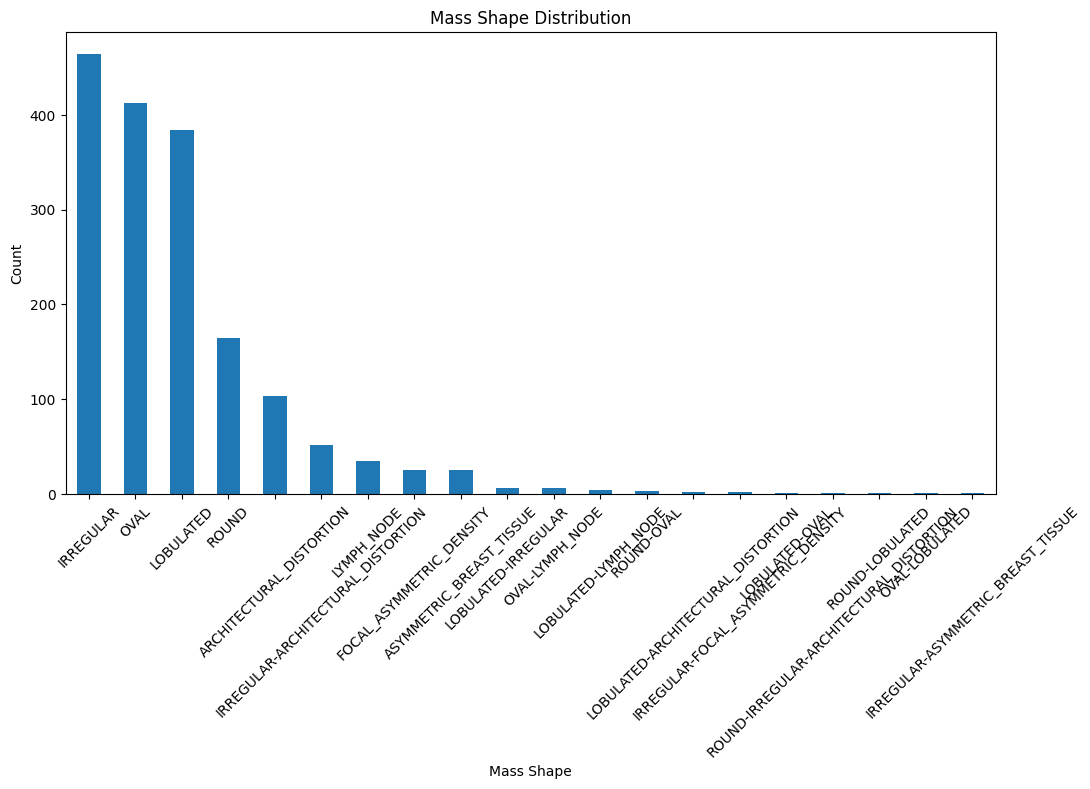

In [ ]:
plt.figure(figsize=(12,6))

data['mass shape'].value_counts().plot(
    kind='bar'
)

plt.title('Mass Shape Distribution')
plt.xlabel('Mass Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import glob

csv_files = glob.glob('/content/ddsm/**/*.csv', recursive=True)

mass_count = 0
calc_count = 0

for file in csv_files:
    df = pd.read_csv(file)

    if 'mass' in file.lower():
        mass_count += len(df)

    elif 'calc' in file.lower():
        calc_count += len(df)

print("Mass cases:", mass_count)
print("Calcification cases:", calc_count)

Mass cases: 1696
Calcification cases: 1872


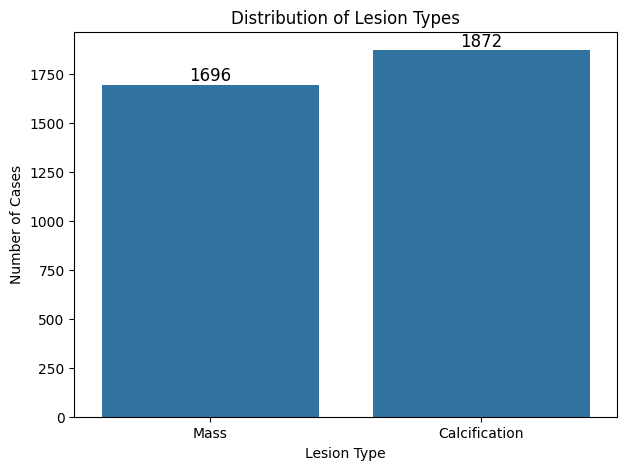

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

lesion_df = pd.DataFrame({
    'Lesion Type': ['Mass', 'Calcification'],
    'Count': [mass_count, calc_count]
})

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x='Lesion Type',
    y='Count',
    data=lesion_df
)

# Add numbers on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('Distribution of Lesion Types')
plt.xlabel('Lesion Type')
plt.ylabel('Number of Cases')
plt.show()

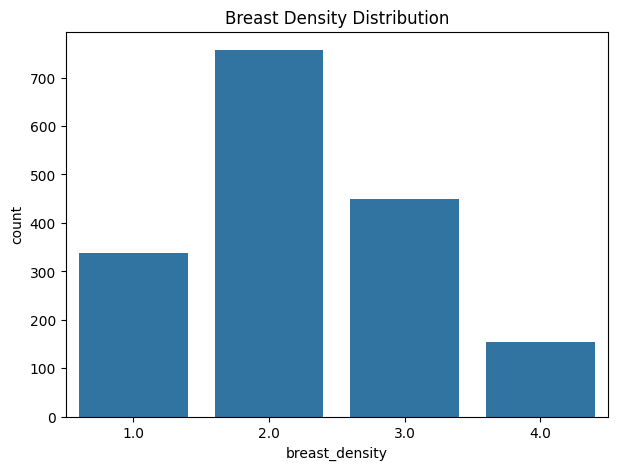

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='breast_density',
    data=data
)

plt.title('Breast Density Distribution')
plt.show()

In [ ]:
print("Average Width:",
      size_df['Width'].mean())

print("Average Height:",
      size_df['Height'].mean())

Average Width: 2179.8933281234736
Average Height: 3549.7788414574584


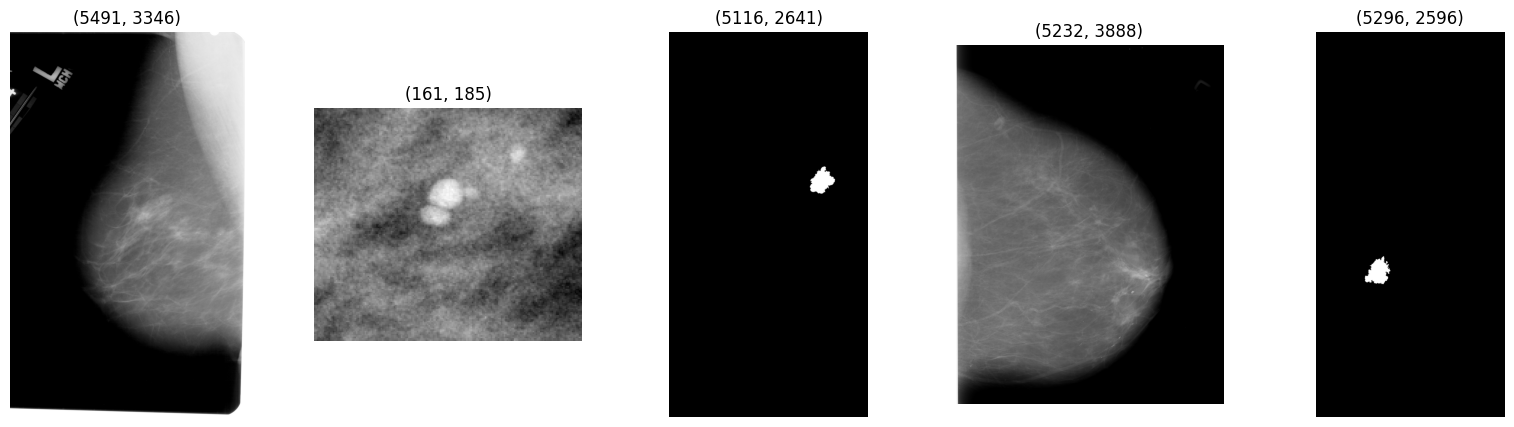

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

sample_paths = random.sample(image_paths, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, path in zip(axes, sample_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(img.shape)
    ax.axis('off')

plt.show()

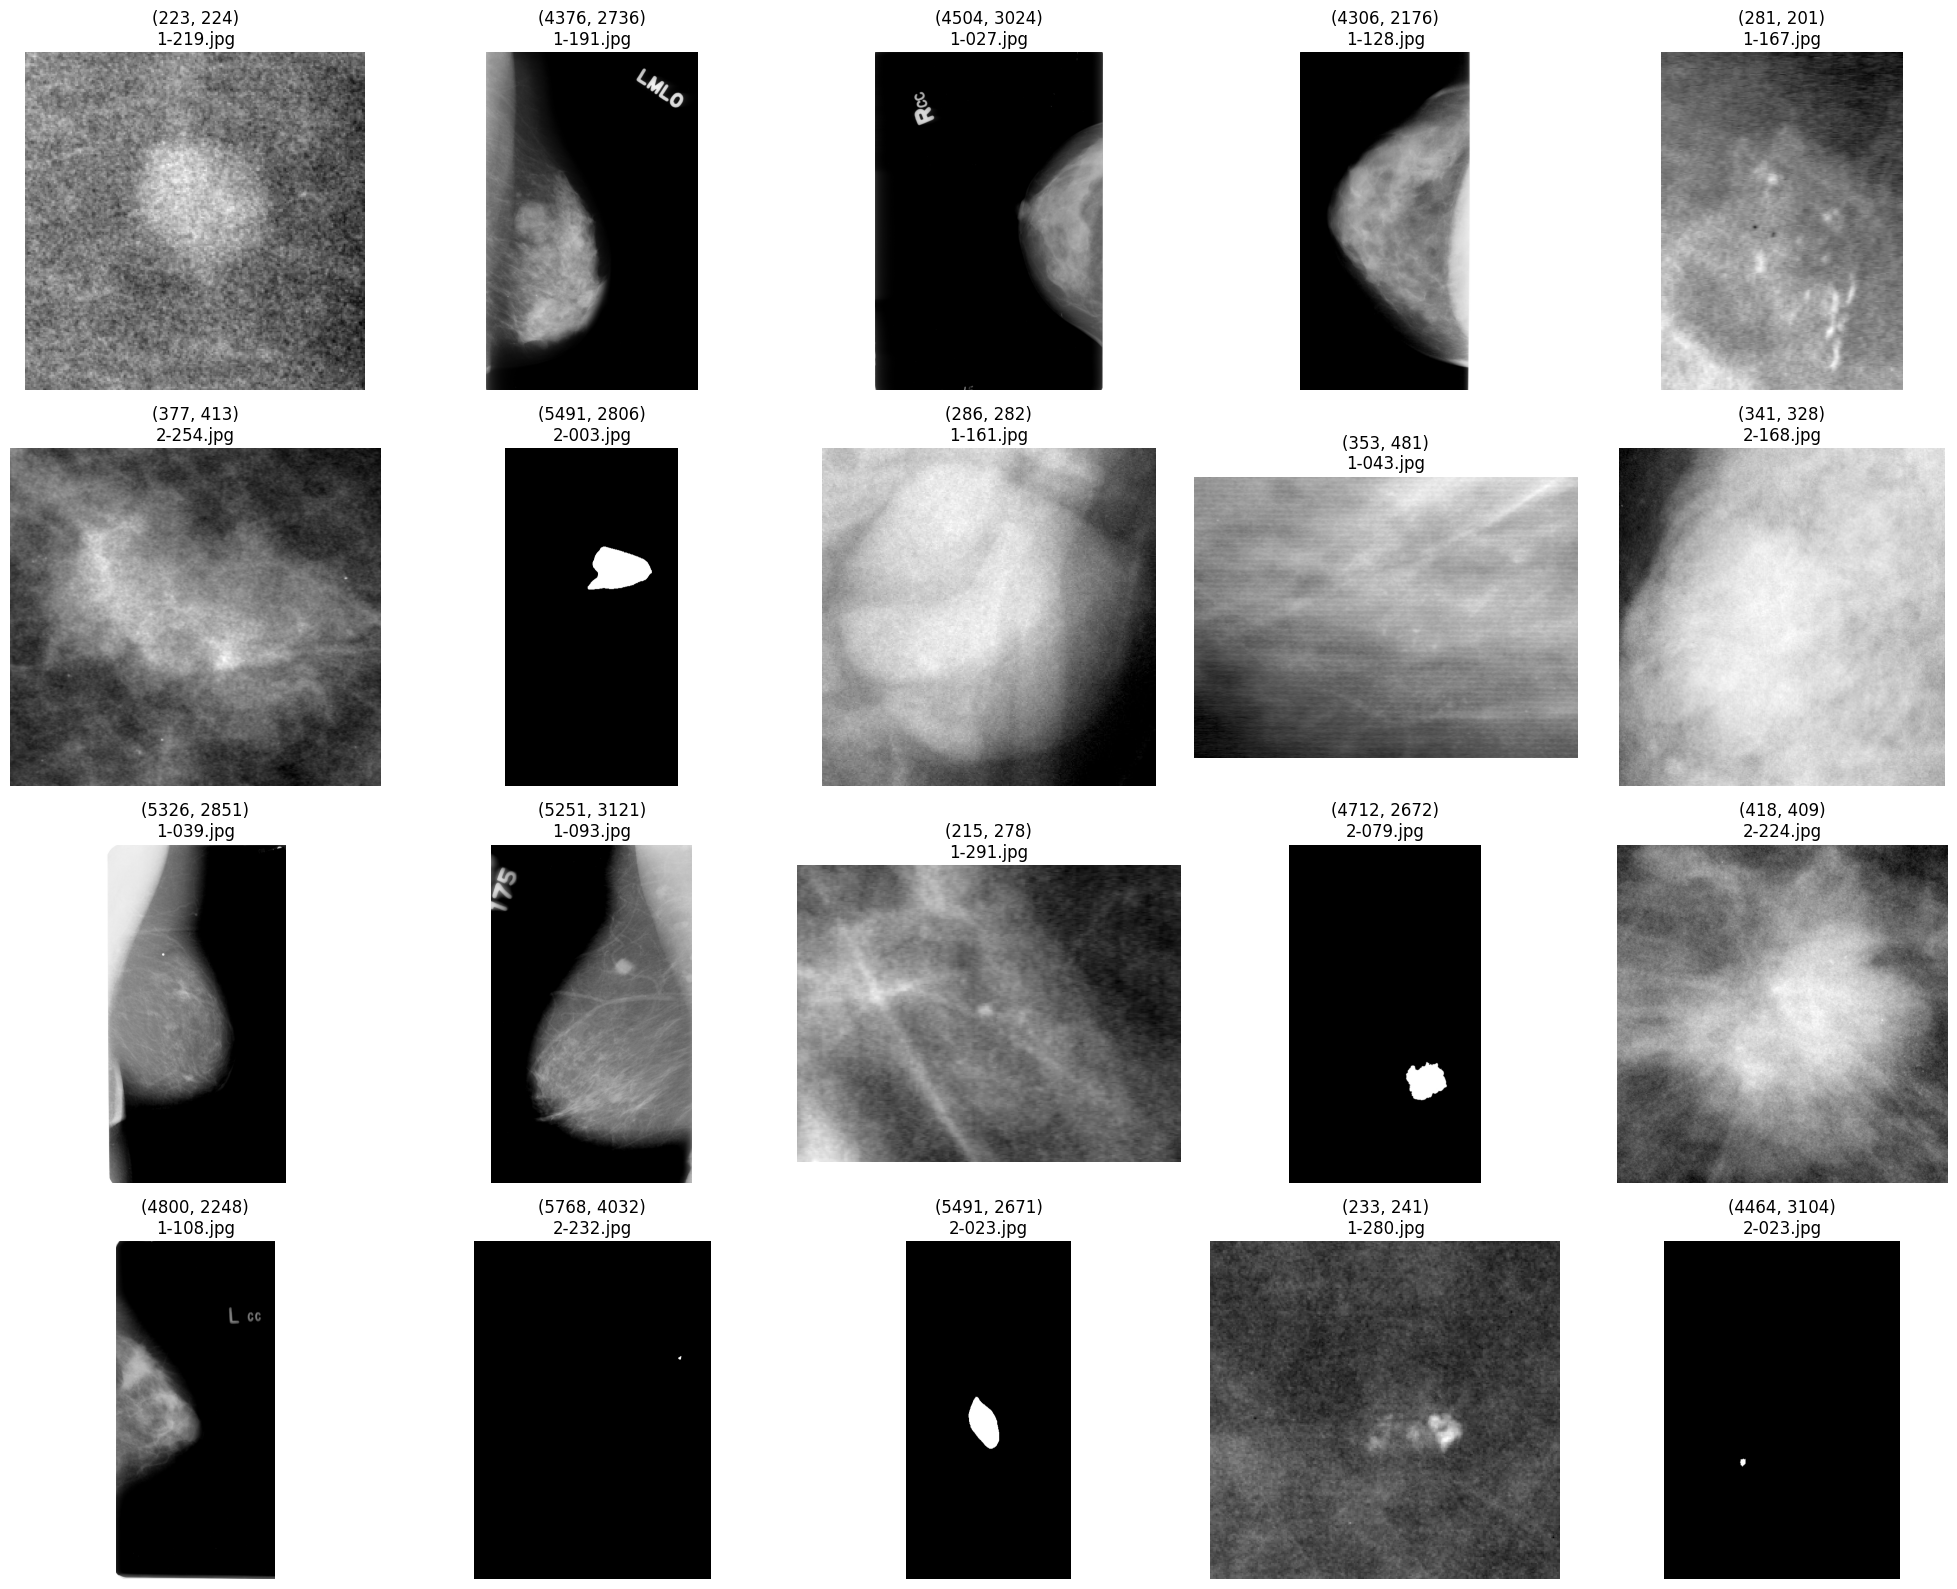

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

sample_paths = random.sample(image_paths, 20)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for ax, path in zip(axes.ravel(), sample_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img.shape}\n{path.split('/')[-1]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
for p in image_paths[:30]:
    print(os.path.basename(p))

1-251.jpg
2-271.jpg
1-293.jpg
1-271.jpg
2-274.jpg
1-273.jpg
1-150.jpg
1-128.jpg
1-027.jpg
1-059.jpg
1-190.jpg
2-168.jpg
1-229.jpg
2-227.jpg
1-249.jpg
2-166.jpg
1-059.jpg
1-110.jpg
1-064.jpg
2-128.jpg
1-150.jpg
1-183.jpg
2-058.jpg
1-104.jpg
2-190.jpg
1-189.jpg
1-273.jpg
2-095.jpg
1-096.jpg
1-260.jpg


In [ ]:
for p in image_paths[:20]:
    print(p)

/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.185401704612037921031992536423384183051/1-251.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334/2-271.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334/1-293.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.201343023312572202611149257572758552350/1-271.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852/2-274.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852/1-273.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.156805203412920037240953312442485485632/1-150.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.206569118911905186733493208503657964099/1-128.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.19233593713150936611511674154223618351/1-027.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.269202987711986825109322228633022698364/1-059.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.26446110461168627

In [ ]:
import pandas as pd

df = pd.read_csv('/content/dicom_info.csv')

In [ ]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [ ]:
full_df = df[df['SeriesDescription'] == 'full mammogram images']
mask_df = df[df['SeriesDescription'] == 'ROI mask images']
crop_df = df[df['SeriesDescription'] == 'cropped images']

print("Full mammograms:", len(full_df))
print("Masks:", len(mask_df))
print("Cropped:", len(crop_df))

Full mammograms: 2857
Masks: 3247
Cropped: 3567


In [ ]:
print(df.columns)

Index(['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated',
       'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate',
       'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber',
       'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate',
       'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',
       'PhotometricInterpretation', 'PixelRepresentation',
       'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID',
       'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer',
       'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription',
       'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue',
       'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID',
       'StudyTime'],
      dtype='object')


In [ ]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [ ]:
patient = df['PatientID'].iloc[0]

df[df['PatientID'] == patient][
    ['PatientID',
     'SeriesDescription',
     'image_path',
     'StudyInstanceUID',
     'SeriesInstanceUID']
]

,PatientID,SeriesDescription,image_path,StudyInstanceUID,SeriesInstanceUID
0,Mass-Training_P_01265_RIGHT_MLO_1,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...
4677,Mass-Training_P_01265_RIGHT_MLO_1,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153292...,1.3.6.1.4.1.9590.100.1.2.278094251111384326418...,1.3.6.1.4.1.9590.100.1.2.153292899210265727229...


In [ ]:
df.groupby(
    ['PatientID', 'SeriesDescription']
).size().unstack(fill_value=0).head(20)

SeriesDescription,ROI mask images,cropped images,full mammogram images
PatientID,,,
Calc-Test_P_00038_LEFT_CC_1,0,1,0
Calc-Test_P_00038_LEFT_MLO_1,0,1,0
Calc-Test_P_00038_RIGHT_CC_1,0,1,0
Calc-Test_P_00038_RIGHT_CC_2,0,1,0
Calc-Test_P_00038_RIGHT_MLO_1,0,1,0
Calc-Test_P_00038_RIGHT_MLO_2,0,1,0
Calc-Test_P_00041_LEFT_CC_2,0,1,0
Calc-Test_P_00041_LEFT_MLO_2,0,1,0
Calc-Test_P_00077_LEFT_CC_1,0,1,0


In [ ]:
df[['SeriesDescription', 'image_path']].head(10)

,SeriesDescription,image_path
0,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
1,full mammogram images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2,full mammogram images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
3,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
4,NaN,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
5,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
6,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
7,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
8,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
9,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...


In [ ]:
df = df.dropna(subset=['SeriesDescription']).copy()

In [ ]:
mammo_df = df[df['SeriesDescription'] == 'full mammogram images']
mask_df = df[df['SeriesDescription'] == 'ROI mask images']
crop_df = df[df['SeriesDescription'] == 'cropped images']

print(len(mammo_df))
print(len(mask_df))
print(len(crop_df))

2857
3247
3567


In [ ]:
import os

df['exists'] = df['image_path'].apply(os.path.exists)

df['exists'].value_counts()

,count
exists,
False,9671


In [ ]:
print(df['image_path'].iloc[0])

CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg


In [ ]:
!ls /content
!find /content -type d | head -20

cbis-ddsm-breast-cancer-image-dataset.zip  mass_case_description_test_set.csv
ddsm					   mass_case_description_train_set.csv
dicom_info.csv				   meta.csv
kaggle.json				   sample_data
/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.06.04
/content/.config/configurations
/content/ddsm
/content/ddsm/jpeg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.185401704612037921031992536423384183051
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.310075191611275148310883493352075805334
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.201343023312572202611149257572758552350
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.200877199010883633131989495271471001852
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.156805203412920037240953312442485485632
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.206569118911905186733493208503657964099
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.19233593713150936611511674154223618351
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.2692029877119868251093222286330226983

In [ ]:
import os

df['full_path'] = df['image_path'].str.replace(
    'CBIS-DDSM/jpeg',
    '/content/ddsm/jpeg',
    regex=False
)

df['exists'] = df['full_path'].apply(os.path.exists)

df['exists'].value_counts()

,count
exists,
True,9671


In [ ]:
mammo_df = df[
    df['SeriesDescription'] == 'full mammogram images'
].copy()

mask_df = df[
    df['SeriesDescription'] == 'ROI mask images'
].copy()

print("Full mammograms:", len(mammo_df))
print("ROI masks:", len(mask_df))

Full mammograms: 2857
ROI masks: 3247


In [ ]:
df.groupby('PatientID')['SeriesDescription'].value_counts().head(30)

,,count
PatientID,SeriesDescription,
Calc-Test_P_00038_LEFT_CC_1,cropped images,1
Calc-Test_P_00038_LEFT_MLO_1,cropped images,1
Calc-Test_P_00038_RIGHT_CC_1,cropped images,1
Calc-Test_P_00038_RIGHT_CC_2,cropped images,1
Calc-Test_P_00038_RIGHT_MLO_1,cropped images,1
Calc-Test_P_00038_RIGHT_MLO_2,cropped images,1
Calc-Test_P_00041_LEFT_CC_2,cropped images,1
Calc-Test_P_00041_LEFT_MLO_2,cropped images,1
Calc-Test_P_00077_LEFT_CC_1,cropped images,1


In [ ]:
df[df['PatientID'].str.contains('Calc-Test_P_00141', na=False)][
    ['PatientID',
     'SeriesDescription',
     'full_path']
]

,PatientID,SeriesDescription,full_path
3484,Calc-Test_P_00141_LEFT_MLO_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.31...
4190,Calc-Test_P_00141_LEFT_CC_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.40...
6098,Calc-Test_P_00141_LEFT_MLO,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.59...
9237,Calc-Test_P_00141_LEFT_CC,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.31...


In [ ]:
df[df['PatientID'].str.contains('Mass-Training_P_01265', na=False)][
    ['PatientID',
     'SeriesDescription',
     'full_path']
]

,PatientID,SeriesDescription,full_path
0,Mass-Training_P_01265_RIGHT_MLO_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.12...
1771,Mass-Training_P_01265_RIGHT_CC,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.61...
4677,Mass-Training_P_01265_RIGHT_MLO_1,ROI mask images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.15...
4723,Mass-Training_P_01265_RIGHT_CC_1,ROI mask images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.16...
5067,Mass-Training_P_01265_RIGHT_CC_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.99...
7500,Mass-Training_P_01265_RIGHT_MLO,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.25...


In [ ]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row['PatientID']] = row['full_path']

In [ ]:
pairs = []

for _, row in mask_df.iterrows():

    mask_id = row['PatientID']
    mask_path = row['full_path']

    # Remove _1, _2, ...
    base_id = mask_id.rsplit('_', 1)[0]

    if base_id in mammo_dict:
        pairs.append(
            (
                mammo_dict[base_id],
                mask_path
            )
        )

print("Total pairs:", len(pairs))

Total pairs: 3242


In [ ]:
for i in range(5):
    print("Image :", pairs[i][0])
    print("Mask  :", pairs[i][1])
    print("-"*80)

Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.244778268913364488803695681471339327301/1-006.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg
--------------------------------------------------------------------------------
Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.121959290711029067138836794212407572353/1-048.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/2-127.jpg
--------------------------------------------------------------------------------
Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.350546038712624038408433082083902639722/1-106.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.jpg
--------------------------------------------------------------------------------
Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590

In [ ]:
for i in range(5):
    img, mask = pairs[i]
    print("Image :", img)
    print("Mask  :", mask)
    print("Image PatientID:", mammo_df[mammo_df['full_path'] == img]['PatientID'].values)
    print("Mask PatientID :", mask_df[mask_df['full_path'] == mask]['PatientID'].values)
    print("-"*80)

Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.244778268913364488803695681471339327301/1-006.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg
Image PatientID: ['Calc-Training_P_00181_RIGHT_CC']
Mask PatientID : ['Calc-Training_P_00181_RIGHT_CC_1']
--------------------------------------------------------------------------------
Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.121959290711029067138836794212407572353/1-048.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/2-127.jpg
Image PatientID: ['Calc-Training_P_01015_LEFT_CC']
Mask PatientID : ['Calc-Training_P_01015_LEFT_CC_1']
--------------------------------------------------------------------------------
Image : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.350546038712624038408433082083902639722/1-106.jpg
Mask  : /content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.jpg
Image PatientID:

In [ ]:
meta = pd.read_csv('/content/meta.csv')
meta.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


In [ ]:
meta['SeriesDescription'].value_counts()

,count
SeriesDescription,
ROI mask images,3565
full mammogram images,3103
cropped images,107


In [ ]:
full_meta = meta[
    meta['SeriesDescription'] == 'full mammogram images'
].copy()

mask_meta = meta[
    meta['SeriesDescription'] == 'ROI mask images'
].copy()

crop_meta = meta[
    meta['SeriesDescription'] == 'cropped images'
].copy()

print(len(full_meta))
print(len(mask_meta))
print(len(crop_meta))

3103
3565
107


In [ ]:
common = set(full_meta['StudyInstanceUID']) & \
         set(mask_meta['StudyInstanceUID'])

print("Common studies:", len(common))

Common studies: 0


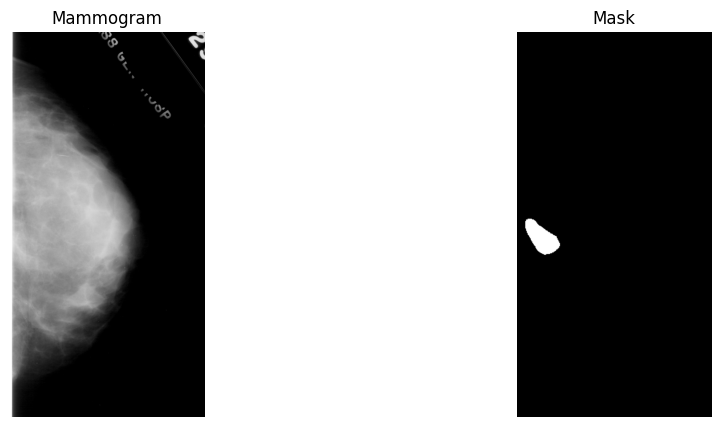

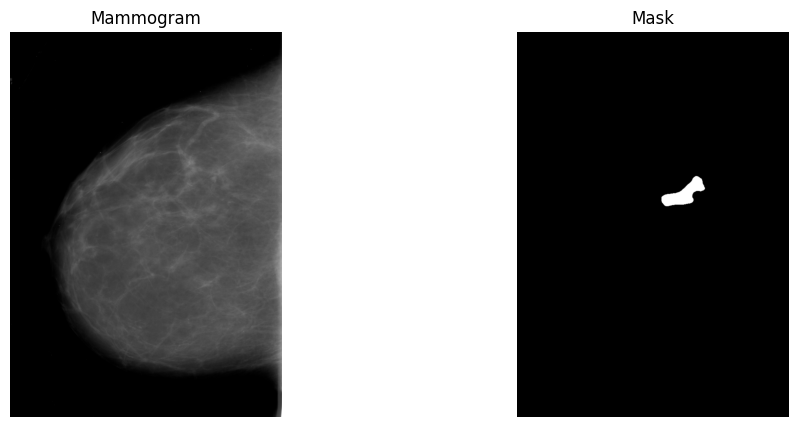

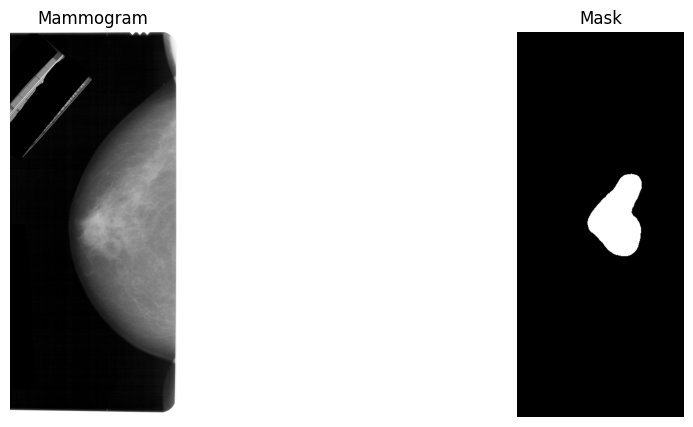

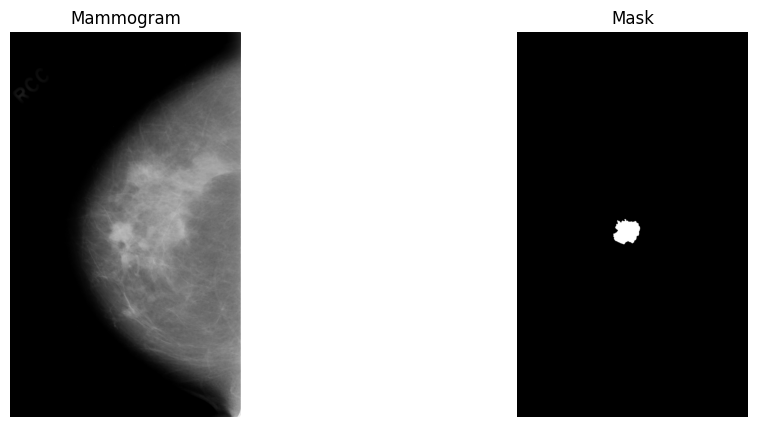

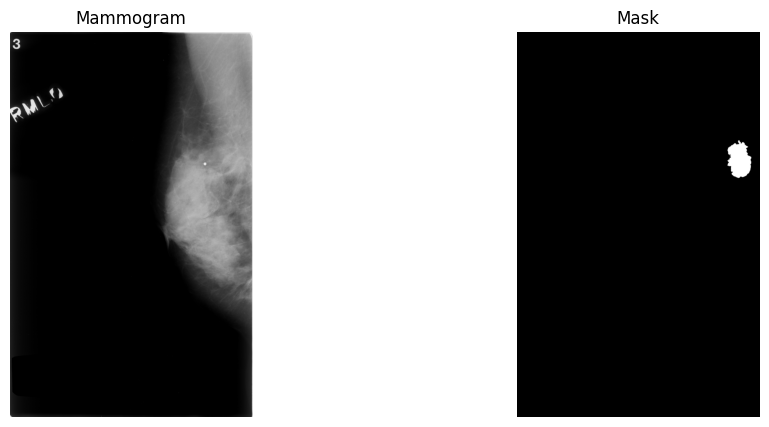

In [ ]:
import cv2
import matplotlib.pyplot as plt

for i in range(5):
    img_path, mask_path = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Mammogram")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Mask")
    ax[1].axis('off')

    plt.show()

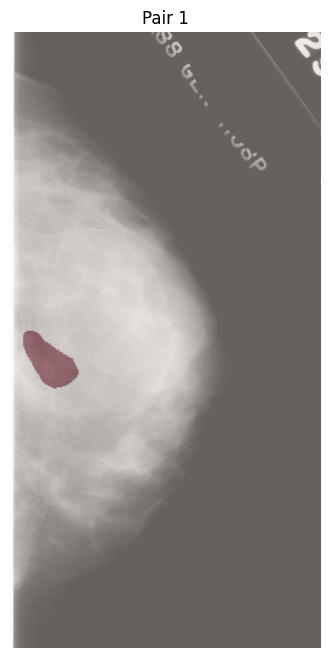

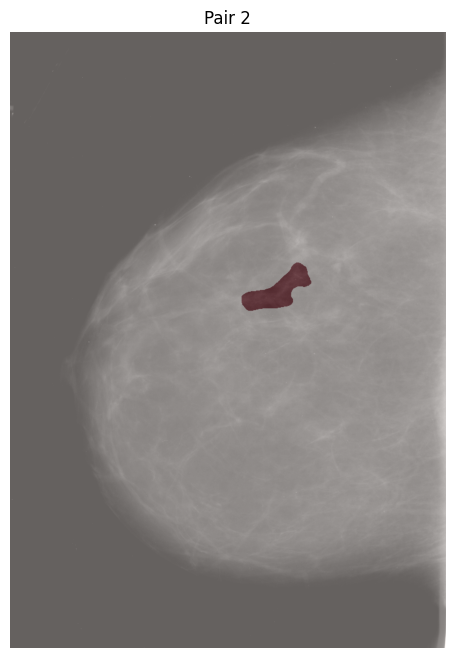

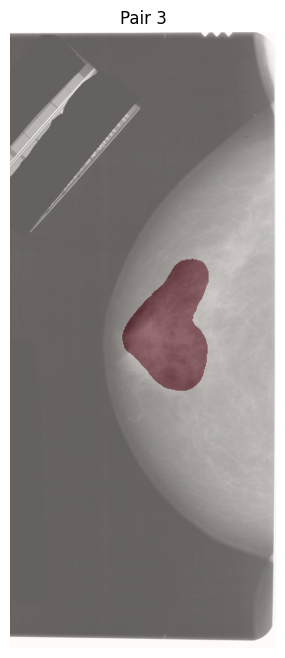

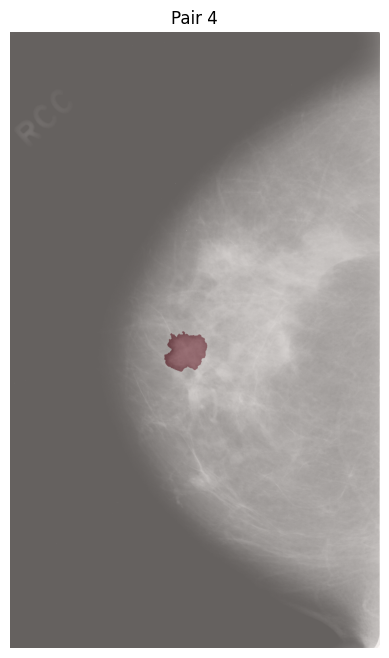

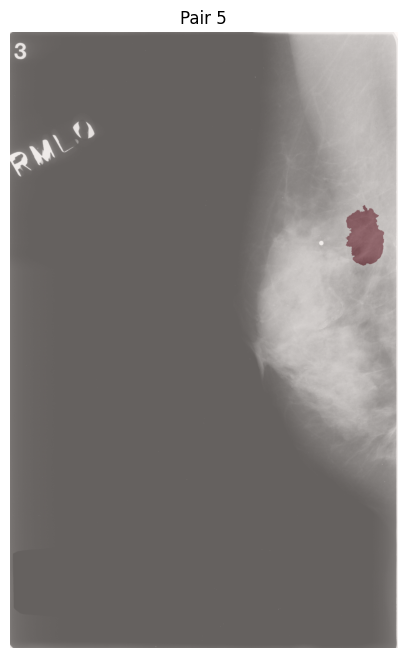

In [ ]:
for i in range(5):
    img_path, mask_path = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    mask = cv2.resize(
        mask,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, cmap='Reds', alpha=0.4)
    plt.title(f'Pair {i+1}')
    plt.axis('off')
    plt.show()

In [ ]:
import cv2
import numpy as np

def right_orientation(img):
    """
    Make every mammogram face the same direction.
    If the breast is on the left half, flip horizontally.
    """

    h, w = img.shape

    left_half = img[:, :w//2]
    right_half = img[:, w//2:]

    left_pixels = np.count_nonzero(left_half)
    right_pixels = np.count_nonzero(right_half)

    # Breast on left -> flip
    if left_pixels > right_pixels:
        img = cv2.flip(img, 1)

    return img

In [ ]:
import cv2
import numpy as np

def remove_background(img):

    # Create binary image
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    # Largest contour = breast region
    largest = max(contours, key=cv2.contourArea)

    # Create mask
    mask = np.zeros_like(img)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    # Keep only breast
    breast = cv2.bitwise_and(img, img, mask=mask)

    return breast

In [ ]:
def preprocess_image(path):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Orientation correction
    img = right_orientation(img)

# Remove background
    img = remove_background(img)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    img = clahe.apply(img)

    img = cv2.GaussianBlur(img, (3,3), 0)

    img = cv2.resize(img, (256,256))

    img = img.astype(np.float32) / 255.0

    return img

In [ ]:
def preprocess_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    mask = right_orientation(mask)

    mask = cv2.resize(
        mask,
        (256, 256),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (mask > 0).astype(np.uint8)

    return mask

In [ ]:
import numpy as np

X = []
Y = []

for img_path, mask_path in pairs:
    X.append(preprocess_image(img_path))
    Y.append(preprocess_mask(mask_path))

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.uint8)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (3242, 256, 256, 1)
Y shape: (3242, 256, 256, 1)


In [ ]:
import os
import cv2

os.makedirs("/content/processed_images", exist_ok=True)
os.makedirs("/content/processed_masks", exist_ok=True)

for i, (img_path, mask_path) in enumerate(pairs):

    img = preprocess_image(img_path)
    mask = preprocess_mask(mask_path)

    cv2.imwrite(
        f"/content/processed_images/img_{i:04d}.png",
        (img * 255).astype("uint8")
    )

    cv2.imwrite(
        f"/content/processed_masks/mask_{i:04d}.png",
        (mask * 255).astype("uint8")
    )

In [ ]:
from tqdm import tqdm
import numpy as np

X = []
Y = []

for img_path, mask_path in tqdm(pairs):
    X.append(preprocess_image(img_path))
    Y.append(preprocess_mask(mask_path))

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.uint8)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

100%|██████████| 3242/3242 [16:10<00:00,  3.34it/s]


X shape: (3242, 256, 256, 1)
Y shape: (3242, 256, 256, 1)


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Create folders
os.makedirs("/content/boxed_images", exist_ok=True)
os.makedirs("/content/roi_images", exist_ok=True)
os.makedirs("/content/roi_masks", exist_ok=True)

ROI_X = []
ROI_Y = []

for i in tqdm(range(len(X))):

    # Convert to uint8
    img = (X[i].squeeze() * 255).astype(np.uint8)
    mask = (Y[i].squeeze() * 255).astype(np.uint8)

    # Find lesion contour
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    # Largest contour
    cnt = max(contours, key=cv2.contourArea)

    # Bounding box
    x, y, w, h = cv2.boundingRect(cnt)

    # Draw bounding box
    boxed = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(boxed, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Save boxed image
    cv2.imwrite(
        f"/content/boxed_images/img_{i:04d}.png",
        boxed
    )

    # Crop ROI
    roi_img = img[y:y+h, x:x+w]
    roi_mask = mask[y:y+h, x:x+w]

    # Resize ROI to fixed size
    roi_img = cv2.resize(roi_img, (128,128), interpolation=cv2.INTER_AREA)
    roi_mask = cv2.resize(roi_mask, (128,128), interpolation=cv2.INTER_NEAREST)

    # Save PNGs
    cv2.imwrite(
        f"/content/roi_images/roi_{i:04d}.png",
        roi_img
    )

    cv2.imwrite(
        f"/content/roi_masks/roi_mask_{i:04d}.png",
        roi_mask
    )

    # Store for training
    ROI_X.append(roi_img/255.0)
    ROI_Y.append(roi_mask//255)

# Convert to numpy arrays
ROI_X = np.array(ROI_X, dtype=np.float32)[..., np.newaxis]
ROI_Y = np.array(ROI_Y, dtype=np.uint8)[..., np.newaxis]

print("ROI_X:", ROI_X.shape)
print("ROI_Y:", ROI_Y.shape)

# Save arrays
np.save("/content/ROI_X.npy", ROI_X)
np.save("/content/ROI_Y.npy", ROI_Y)

100%|██████████| 3242/3242 [00:10<00:00, 303.86it/s]


ROI_X: (3242, 128, 128, 1)
ROI_Y: (3242, 128, 128, 1)


In [ ]:
np.save('/content/X.npy', X)
np.save('/content/Y.npy', Y)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    random_state=42
)

np.save("/content/X_train.npy", X_train)
np.save("/content/Y_train.npy", Y_train)

np.save("/content/X_val.npy", X_val)
np.save("/content/Y_val.npy", Y_val)

np.save("/content/X_test.npy", X_test)
np.save("/content/Y_test.npy", Y_test)

In [ ]:
ROI_X_train, ROI_X_temp, ROI_Y_train, ROI_Y_temp = train_test_split(
    ROI_X, ROI_Y,
    test_size=0.2,
    random_state=42
)

ROI_X_val, ROI_X_test, ROI_Y_val, ROI_Y_test = train_test_split(
    ROI_X_temp, ROI_Y_temp,
    test_size=0.5,
    random_state=42
)

np.save("/content/ROI_X_train.npy", ROI_X_train)
np.save("/content/ROI_Y_train.npy", ROI_Y_train)

np.save("/content/ROI_X_val.npy", ROI_X_val)
np.save("/content/ROI_Y_val.npy", ROI_Y_val)

np.save("/content/ROI_X_test.npy", ROI_X_test)
np.save("/content/ROI_Y_test.npy", ROI_Y_test)

In [ ]:
import shutil
import os

# Create one folder containing everything
os.makedirs("/content/preprocessed_dataset", exist_ok=True)

# Copy folders
shutil.copytree("/content/processed_images",
                "/content/preprocessed_dataset/processed_images",
                dirs_exist_ok=True)

shutil.copytree("/content/processed_masks",
                "/content/preprocessed_dataset/processed_masks",
                dirs_exist_ok=True)

shutil.copytree("/content/boxed_images",
                "/content/preprocessed_dataset/boxed_images",
                dirs_exist_ok=True)

shutil.copytree("/content/roi_images",
                "/content/preprocessed_dataset/roi_images",
                dirs_exist_ok=True)

shutil.copytree("/content/roi_masks",
                "/content/preprocessed_dataset/roi_masks",
                dirs_exist_ok=True)

# Copy numpy arrays
files = [
    "X.npy",
    "Y.npy",
    "ROI_X.npy",
    "ROI_Y.npy"
]

for f in files:
    shutil.copy(f"/content/{f}", f"/content/preprocessed_dataset/{f}")

# Create zip
shutil.make_archive(
    "/content/preprocessed_dataset",
    "zip",
    "/content/preprocessed_dataset"
)

print("ZIP created successfully!")

ZIP created successfully!


In [ ]:
from google.colab import files

files.download("/content/preprocessed_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

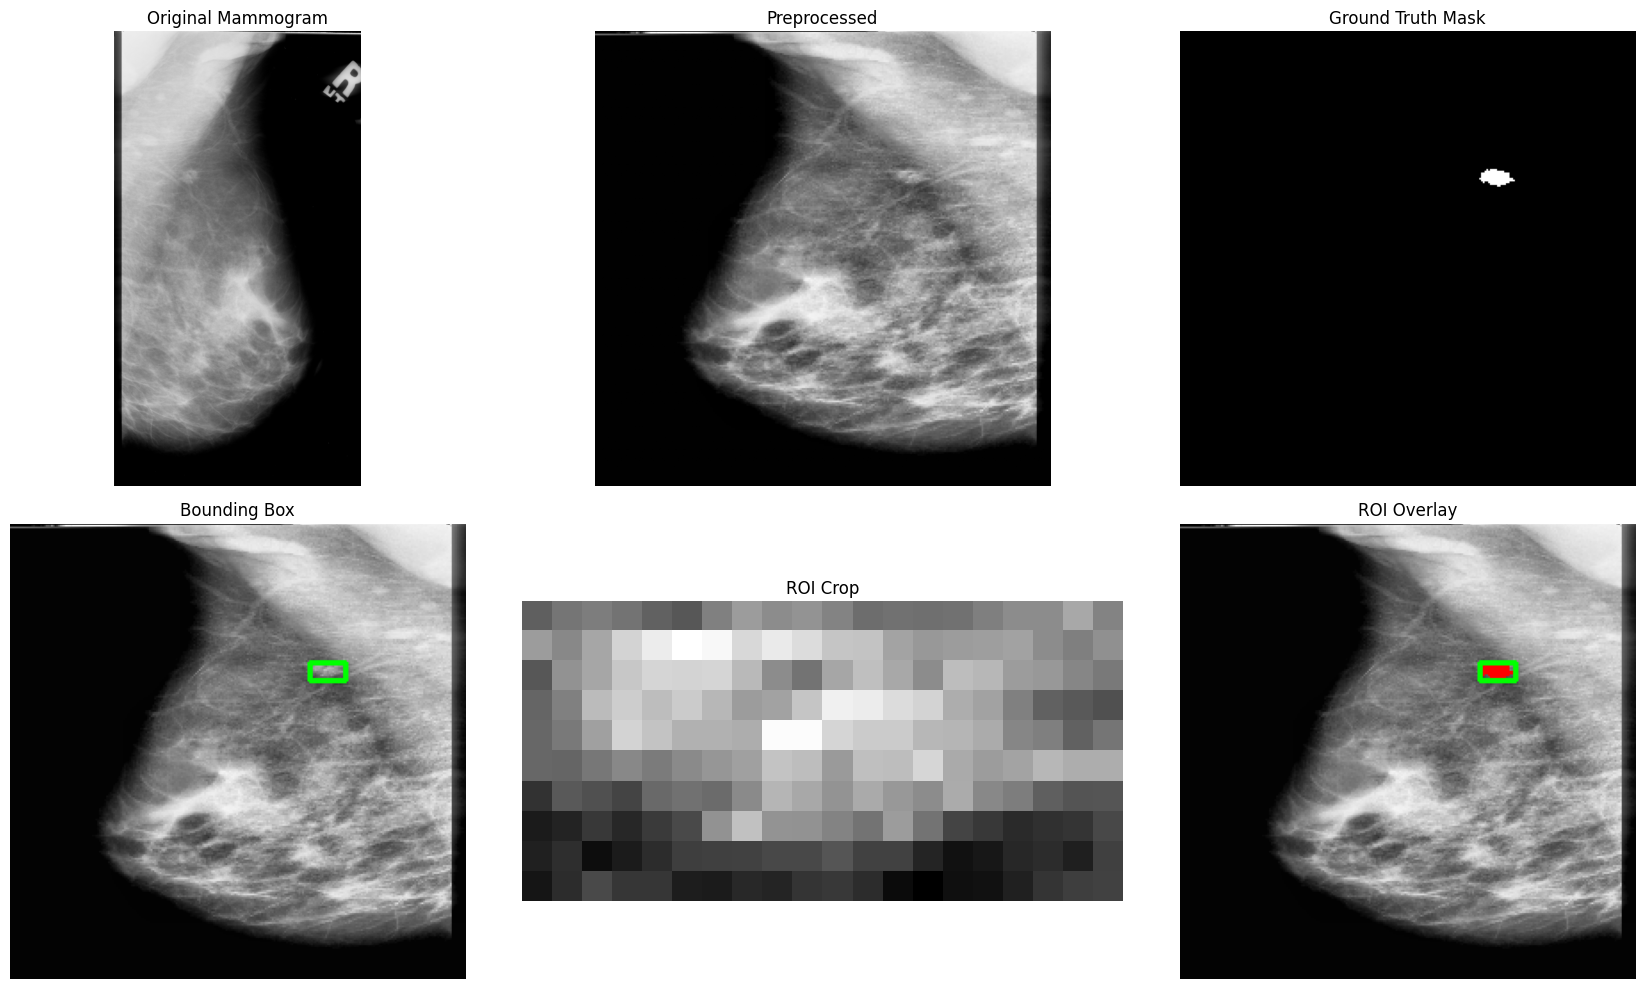

Random Sample Index: 2664


In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Select a random image
idx = random.randint(0, len(pairs)-1)

img_path, mask_path = pairs[idx]

# Original mammogram
original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Preprocessed image and mask
preprocessed = (X[idx].squeeze()*255).astype(np.uint8)
mask = (Y[idx].squeeze()*255).astype(np.uint8)

# Find bounding box
contours, _ = cv2.findContours(mask,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

boxed = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

if len(contours) > 0:

    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    # Draw bounding box
    cv2.rectangle(boxed, (x,y), (x+w,y+h), (0,255,0), 2)

    # ROI
    roi = preprocessed[y:y+h, x:x+w]

    # Overlay
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)
    overlay[mask>0] = [255,0,0]      # lesion in blue
    cv2.rectangle(overlay,(x,y),(x+w,y+h),(0,255,0),2)

else:
    roi = np.zeros((50,50),dtype=np.uint8)
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

# Plot
fig, ax = plt.subplots(2,3,figsize=(18,10))

ax[0,0].imshow(original,cmap='gray')
ax[0,0].set_title("Original Mammogram")
ax[0,0].axis("off")

ax[0,1].imshow(preprocessed,cmap='gray')
ax[0,1].set_title("Preprocessed")
ax[0,1].axis("off")

ax[0,2].imshow(mask,cmap='gray')
ax[0,2].set_title("Ground Truth Mask")
ax[0,2].axis("off")

ax[1,0].imshow(boxed)
ax[1,0].set_title("Bounding Box")
ax[1,0].axis("off")

ax[1,1].imshow(roi,cmap='gray')
ax[1,1].set_title("ROI Crop")
ax[1,1].axis("off")

ax[1,2].imshow(overlay)
ax[1,2].set_title("ROI Overlay")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

print("Random Sample Index:", idx)